In [ ]:
# Controleer en installeer ontbrekende visualisatiepakketten
import importlib.util
import sys
import subprocess

VIS_PACKAGES = {
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

missing_vis = [pkg for pkg, mod in VIS_PACKAGES.items() if importlib.util.find_spec(mod) is None]

if missing_vis:
    print(f"Installeer ontbrekende visualisatiepakketten: {missing_vis}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_vis])
    print("Installatie voltooid. Voer deze cel eventueel opnieuw uit als er nog fouten zijn.")
else:
    print("Alle visualisatiepakketten zijn al geïnstalleerd.")

Installeer ontbrekende visualisatiepakketten: ['matplotlib', 'seaborn']
Installatie voltooid. Voer deze cel eventueel opnieuw uit als er nog fouten zijn.


# Goalkeeper Pipeline Runner

Deze notebook voert de volledige pipeline uit en toont de belangrijkste outputtabellen.

In [ ]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "scikit-learn": "sklearn",
    "xgboost": "xgboost",
    "joblib": "joblib",
}

missing = [
    package
    for package, module_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    print("Installation complete. Re-run this cell if needed.")
else:
    print("All required packages are already installed.")

All required packages are already installed.


In [ ]:
from pathlib import Path
import subprocess
import sys
import pandas as pd

In [ ]:
project_root = Path.cwd().resolve().parent
src_main = project_root / 'src' / 'main.py'
src_train = project_root / 'src' / 'train_model.py'
outputs_tables = project_root / 'outputs' / 'tables'
outputs_models = project_root / 'outputs' / 'models'

print('Project root:', project_root)
print('Main script:', src_main)
print('Train script:', src_train)

Project root: C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project
Main script: C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\src\main.py
Train script: C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\src\train_model.py


## 1. Run volledige feature + ranking pipeline

In [ ]:
result_main = subprocess.run([sys.executable, str(src_main)], capture_output=True, text=True)
print('Return code:', result_main.returncode)
print(result_main.stdout)
if result_main.stderr.strip():
    print('STDERR:\n', result_main.stderr)

Return code: 0
Saved interim features: origin=24732 rows, current=3888 rows, missing_log=32 rows, normalized_origin=24732 rows, normalized_current=3888 rows, origin_players=615 rows, current_players=217 rows, current_ranking=217 rows, successful_gks=29 rows, successful_profiles=29 rows, similarity_rows=109 rows, output_a=217 rows, output_b=217 rows, potential_rows=109



## 2. Run potential model training apart (optioneel, voor metrics)

In [ ]:
result_train = subprocess.run([sys.executable, str(src_train)], capture_output=True, text=True)
print('Return code:', result_train.returncode)
print(result_train.stdout)
if result_train.stderr.strip():
    print('STDERR:\n', result_train.stderr)

Return code: 0
{'metrics': {'logistic_regression': {'roc_auc': 0.9656283566058002, 'f1': 0.7924528301886793, 'recall': 1.0}, 'random_forest': {'roc_auc': 0.9659863945578232, 'f1': 0.631578947368421, 'recall': 0.5714285714285714}, 'xgboost': {'roc_auc': 0.9684926602219835, 'f1': 0.7272727272727273, 'recall': 0.7619047619047619}}, 'feature_cols': ['age', 'matches_count', 'origin_median', 'current_median', 'step', 'shot_stopping_consistency', 'distribution_consistency', 'overall_consistency'], 'potential_rows': 109}



## 3. Belangrijkste outputs controleren

In [ ]:
expected_files = [
    outputs_tables / 'final_goalkeeper_rankings.csv',
    outputs_tables / 'output_a_main_ranking.csv',
    outputs_tables / 'output_b_comparison.csv',
    outputs_tables / 'potential_ranking.csv',
    outputs_tables / 'successful_gks_young_profiles.csv',
    outputs_tables / 'young_similarity_output.csv',
    outputs_models / 'potential_model.pkl',
]

for fp in expected_files:
    print(f'{fp.name}:', 'OK' if fp.exists() else 'MISSING')

final_goalkeeper_rankings.csv: OK
output_a_main_ranking.csv: OK
output_b_comparison.csv: OK
potential_ranking.csv: OK
successful_gks_young_profiles.csv: OK
young_similarity_output.csv: OK
potential_model.pkl: OK


## 4. Finale ranking preview

In [ ]:
final_path = outputs_tables / 'final_goalkeeper_rankings.csv'
final_df = pd.read_csv(final_path)
print('Rows:', len(final_df))
print('Columns:', len(final_df.columns))
final_df.head(10)

Rows: 217
Columns: 28


,player_name,age,club,matches_used,shot_stopping_score,handling_score,distribution_score,sweeping_score,reliability_score,consistency_score,...,similar_gk_1_young_age,similar_gk_1_shot_stopping,similar_gk_1_handling,similar_gk_1_distribution,similar_gk_1_sweeping,similar_gk_1_reliability,similar_gk_2,similarity_score_2,similar_gk_3,similarity_score_3
0,Finn Kotyrba,22.0,VfL Bochum II,1,59.845541,81.288329,37.479268,61.642396,45.707240,NaN,...,24.0,46.842607,67.390760,50.774728,46.822454,47.711934,Jean Butez,0.977452,Brent Gabriël,0.976842
1,Kevin Müller,34.0,FC Schalke 04,2,52.834916,77.689224,38.495932,51.924903,64.221302,44.305572,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Rody de Boer,28.0,Aalborg BK,1,66.025872,45.735301,42.529149,52.555523,68.141460,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Joël Drommel,29.0,PSV Eindhoven II,7,60.035079,57.971215,50.093907,64.029701,54.192663,44.527642,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Alexander Brunst,30.0,SV Darmstadt 98,3,51.904125,56.051640,49.339930,71.971902,62.701049,42.825175,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Nick Olij,30.0,PSV Eindhoven II,1,61.244614,57.307214,59.640948,38.553349,54.290989,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Nedeljko Stojisic,28.0,OFK Belgrad,2,59.822025,55.635681,39.318476,36.297034,71.958017,43.705709,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Marko Gudžulić,23.0,CF Estrela Amadora SAD,1,60.663107,58.760494,47.728983,39.242943,56.567656,NaN,...,26.0,54.632191,46.781929,51.948979,42.696590,54.983021,Hervé Koffi,0.994018,Antonín Kinský,0.993399
8,Taishi Brandon Nozawa,23.0,Royal Antwerpen FC,11,54.877963,59.886831,44.121938,48.969816,63.971095,40.530490,...,22.0,51.884047,53.351409,47.585721,49.694537,56.317256,Marius Müller,0.996141,Hervé Koffi,0.995364
9,Paul Argney,19.0,Le Havre AC,1,58.167114,52.603423,81.658022,39.163867,39.858323,NaN,...,24.0,45.246200,51.733811,57.364480,49.487108,42.677675,Luca Petzold,0.972174,Nacho Miras,0.971119


## 5. Top 15 op Potential Score (jonge keepers)

In [ ]:
potential_path = outputs_tables / 'potential_ranking.csv'
potential_df = pd.read_csv(potential_path)
cols = [c for c in ['player_name', 'age', 'current_score', 'potential_score', 'potential_rank', 'confidence_score', 'similar_gk_1', 'similarity_score_1'] if c in potential_df.columns]
potential_df.sort_values('potential_rank').head(15)[cols]

,player_name,age,current_score,potential_score,potential_rank
0,Luca Plogmann,26.0,45.261756,99.681730,1
1,Nahuel Noll,22.0,49.523048,99.668760,2
2,Antonín Kinský,22.0,49.905575,99.657250,3
3,Fabian de Keijzer,25.0,50.007634,99.628060,4
4,Diant Ramaj,24.0,50.595359,99.566250,5
5,Jan Olschowsky,24.0,50.639076,99.457634,6
6,Filip Stanković,24.0,50.182460,99.438240,7
7,Justin Heekeren,25.0,52.022187,99.422750,8
8,Tom de Graaff,21.0,48.820042,99.293670,9
9,Franco Israel,25.0,48.189217,98.958084,10


## 6. Visualisations

All charts are generated from the pipeline outputs and saved to `outputs/visuals/`.

In [ ]:
import sys
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

%matplotlib inline

# Ensure src is importable
src_dir = str(project_root / 'src')
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import visualize
importlib.reload(visualize)

# Keep figures open so they render inline in the notebook
visualize._CLOSE_AFTER_SAVE = False

# Load all data once
tables_dir = project_root / 'outputs' / 'tables'
processed_dir = project_root / 'data' / 'processed'
models_dir = project_root / 'outputs' / 'models'

final_df = pd.read_csv(tables_dir / 'final_goalkeeper_rankings.csv')
output_a_df = pd.read_csv(tables_dir / 'output_a_main_ranking.csv')
potential_df = pd.read_csv(tables_dir / 'potential_ranking.csv')
similarity_df = pd.read_csv(tables_dir / 'young_similarity_output.csv')
origin_df = pd.read_csv(processed_dir / 'origin_player_features.csv')
current_df = pd.read_csv(processed_dir / 'current_player_features.csv')
model_artifact = joblib.load(models_dir / 'potential_model.pkl')

print(f"Loaded: final={len(final_df)}, output_a={len(output_a_df)}, potential={len(potential_df)}, "
      f"similarity={len(similarity_df)}, origin={len(origin_df)}, current={len(current_df)}")

Loaded: final=217, output_a=217, potential=109, similarity=109, origin=615, current=217


### 6.1 Label Distribution
How are goalkeepers distributed across outcome labels (PLAYS, BENCH, DROPPED, STAYED)?

  Saved C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\outputs\visuals\01_label_distribution.png


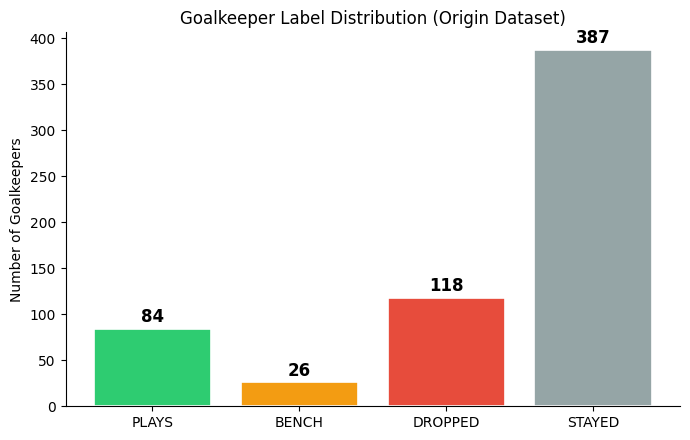

In [ ]:
visualize.plot_label_distribution(origin_df)
plt.show()

### 6.2 Category Score Distributions
Violin plots showing how current goalkeepers score across each performance category.

  Saved C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\outputs\visuals\02_score_distributions.png


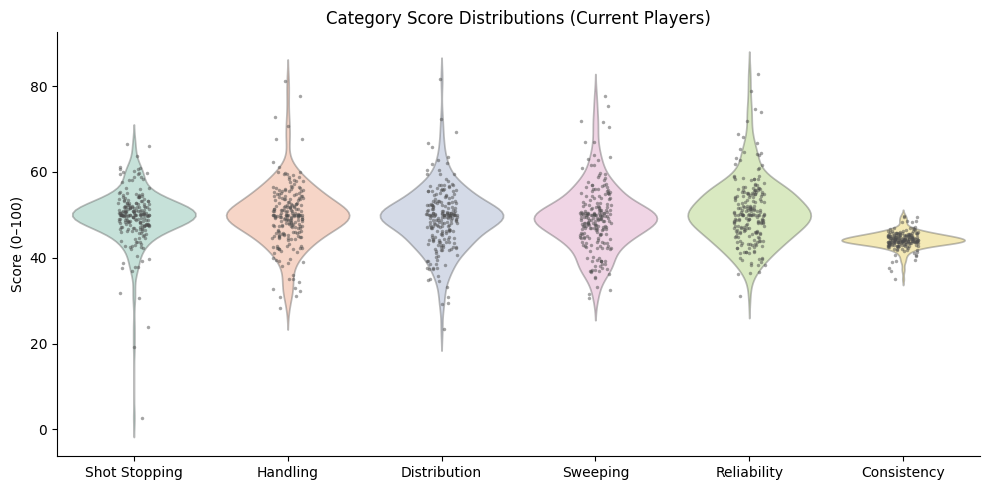

In [ ]:
visualize.plot_score_distributions(current_df)
plt.show()

### 6.3 Score Correlation Heatmap
How do the different performance categories relate to each other?

  Saved C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\outputs\visuals\03_score_correlation.png


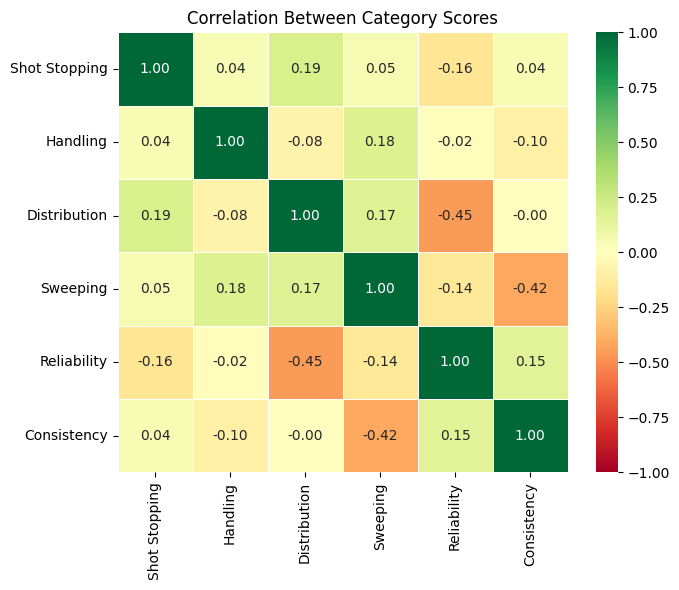

In [ ]:
visualize.plot_score_correlation(current_df)
plt.show()

### 6.4 Current Score vs Potential Score
Do the best current performers also have the highest predicted potential? Coloured by age.

  Saved C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\outputs\visuals\04_current_vs_potential.png


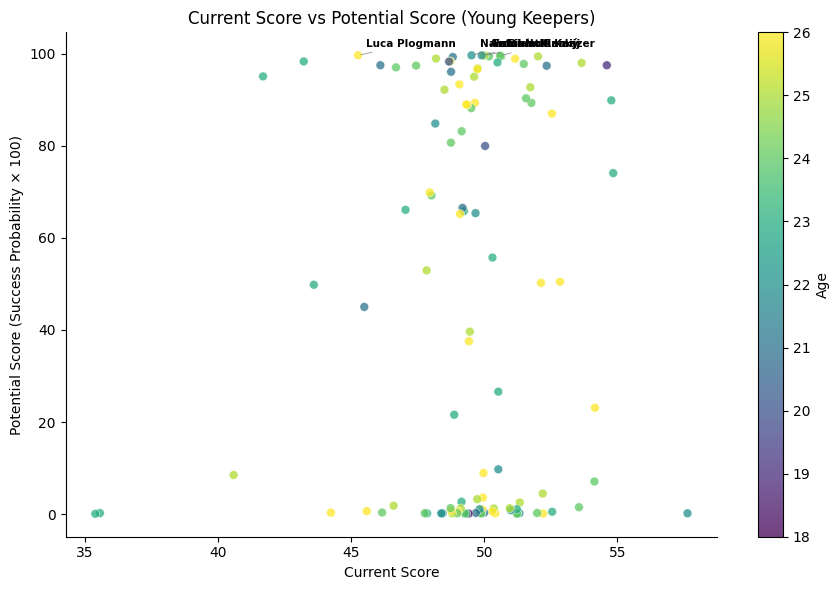

In [ ]:
visualize.plot_current_vs_potential(output_a_df)
plt.show()

### 6.5 Potential Score by Age
Box plots showing how predicted potential varies across age groups.

  Saved C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\outputs\visuals\05_age_vs_potential.png


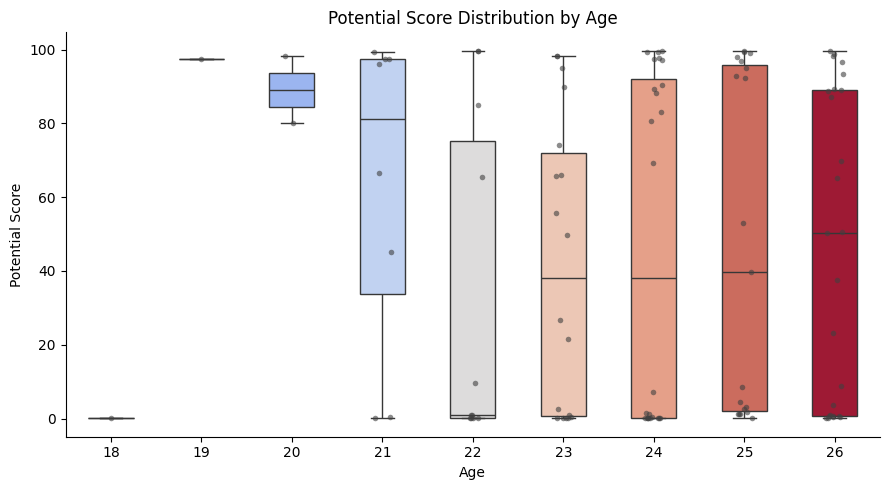

In [ ]:
visualize.plot_age_vs_potential(potential_df)
plt.show()

### 6.6 Radar Charts — Top 3 Potential Players vs Their Historical Match
Spider charts comparing each top-potential goalkeeper to their most similar successful historical keeper.

  Saved C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\outputs\visuals\06_radar_Luca_Plogmann.png


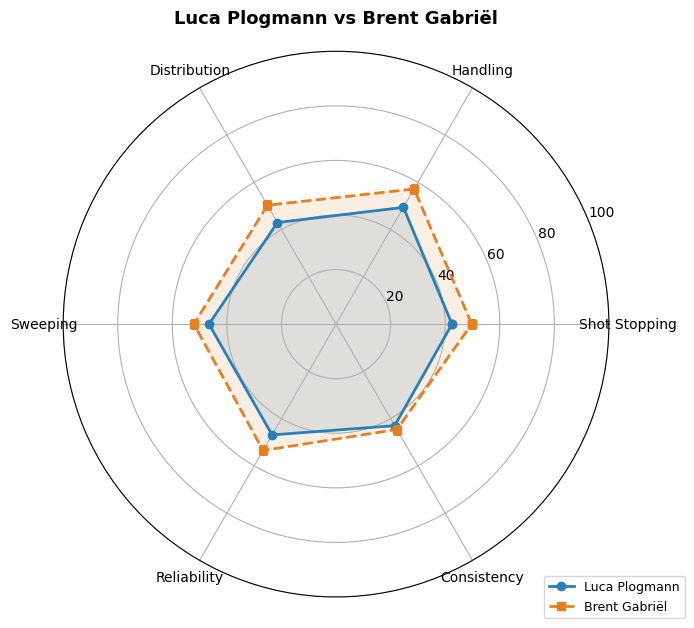

  Saved C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\outputs\visuals\06_radar_Nahuel_Noll.png


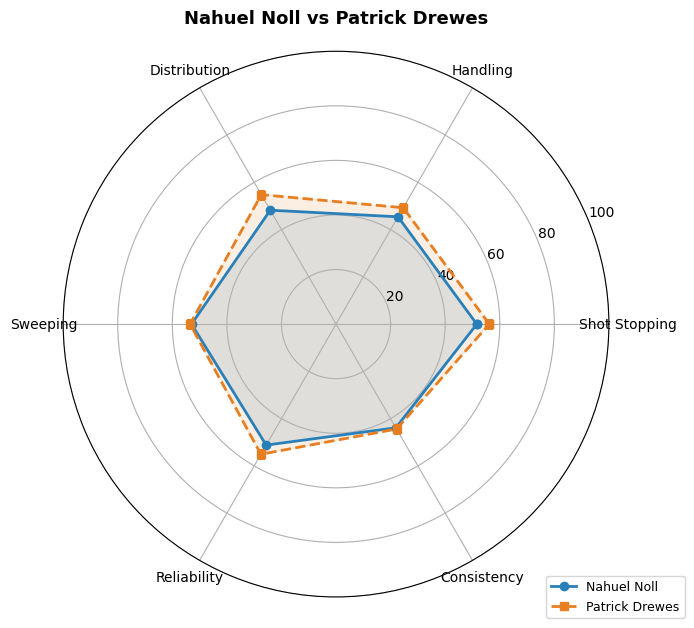

  Saved C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\outputs\visuals\06_radar_Antonín_Kinský.png


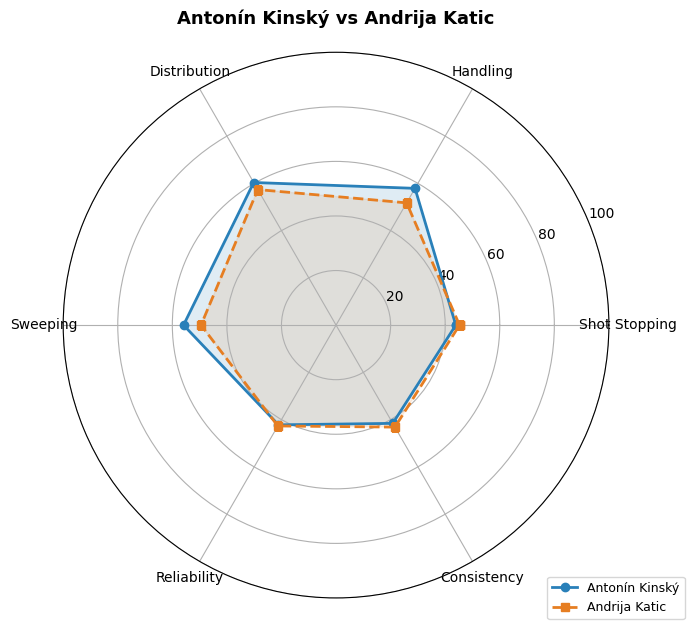

In [ ]:
top3 = output_a_df.dropna(subset=['potential_rank']).nsmallest(3, 'potential_rank')
for _, row in top3.iterrows():
    visualize.plot_player_radar(row)
    plt.show()

### 6.7 Model Performance Comparison
ROC-AUC, F1 and Recall across all three trained models.

  Saved C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\outputs\visuals\07_model_comparison.png


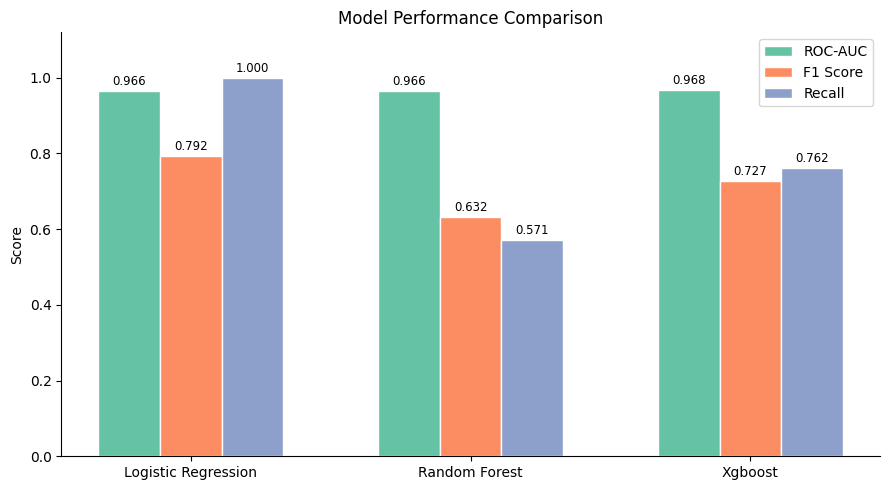

In [ ]:
visualize.plot_model_comparison(model_artifact['metrics'])
plt.show()

### 6.8 XGBoost Feature Importance
Which features matter most for predicting goalkeeper progression?

  Saved C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\outputs\visuals\08_feature_importance.png


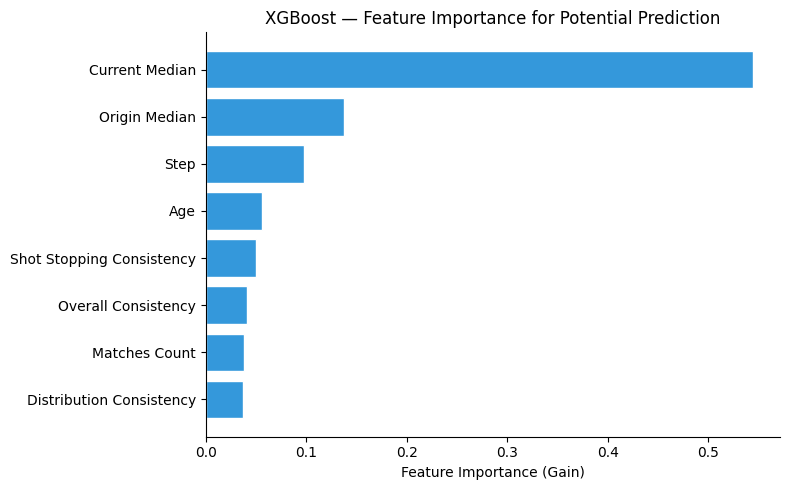

In [ ]:
visualize.plot_feature_importance(model_artifact)
plt.show()

### 6.9 Top 15 Current Ranking — Score Breakdown
Stacked bar chart showing how each category contributes to the top keepers' overall score.

  Saved C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\outputs\visuals\09_top_current_ranking.png


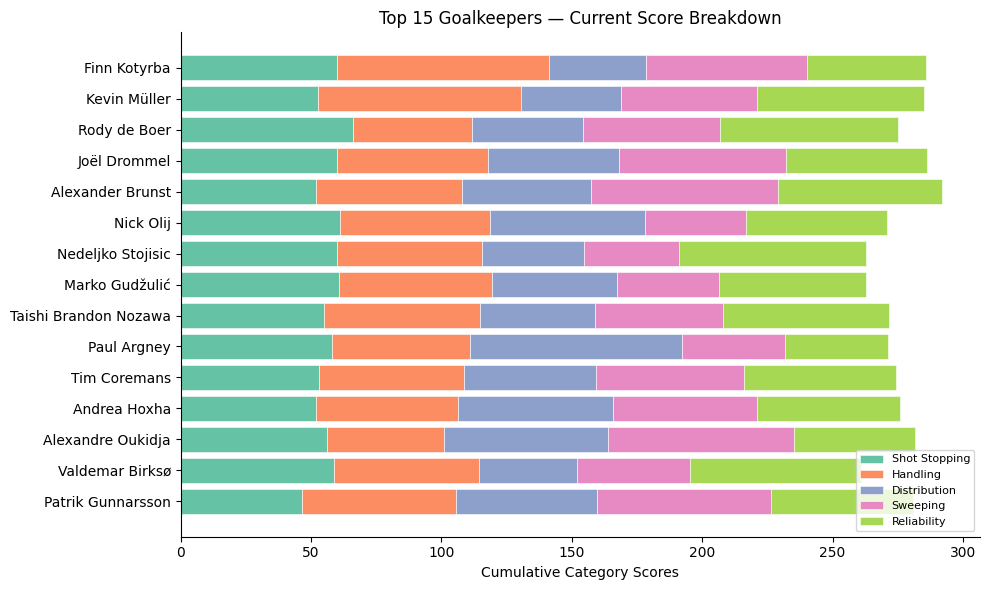

In [ ]:
visualize.plot_top_current_ranking(final_df)
plt.show()

### 6.10 Similarity Score Distribution
How similar are current young keepers to their best historical match?

  Saved C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\outputs\visuals\10_similarity_distribution.png


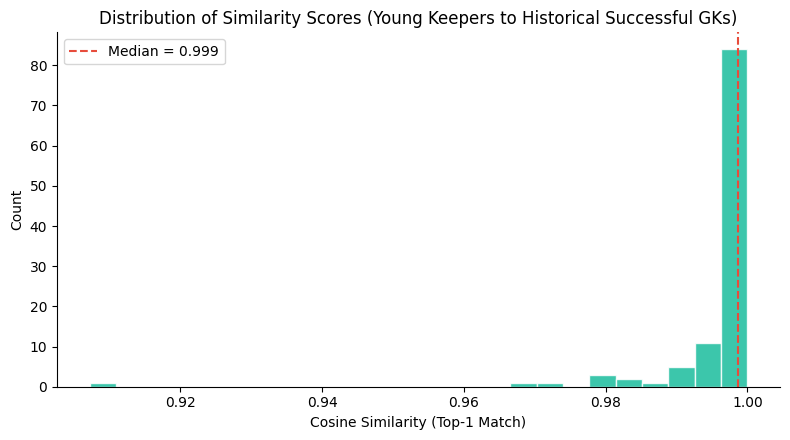

In [ ]:
visualize.plot_similarity_distribution(similarity_df)
plt.show()

### 6.11 Confidence Score vs Current Rank
Do higher-ranked keepers also have higher confidence? Colour = number of matches used.

  Saved C:\Users\ralph\Documents\UCLL\B2S2\Advanced_AI\International week\goalkeeper_project\outputs\visuals\11_confidence_vs_rank.png


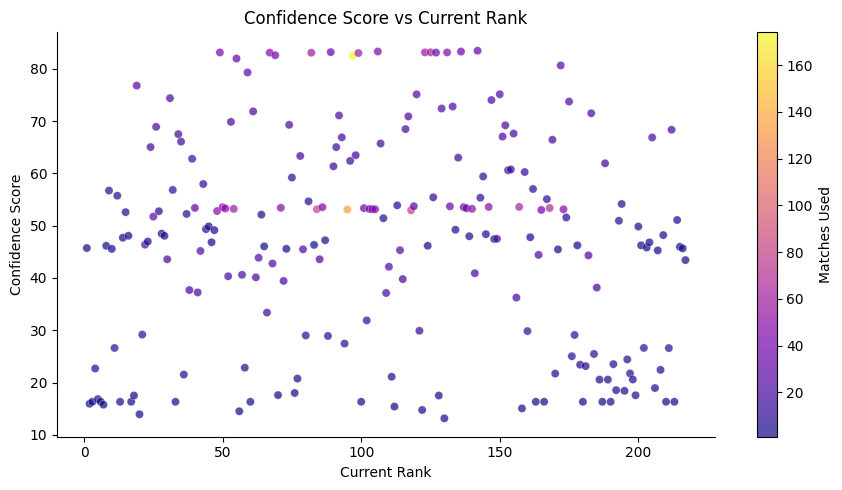

In [ ]:
visualize.plot_confidence_vs_rank(output_a_df)
plt.show()